#### Streaming modes

Boilerplate code

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings("ignore")

load_dotenv()

google_api_key = os.getenv("../.env/GOOGLE_API_KEY")

google_llm=ChatGoogleGenerativeAI(
    temperature=0,
    model="gemini-3.5-flash-lite",
    api_key=google_api_key,
    max_tokens=200
)


Stream experiments


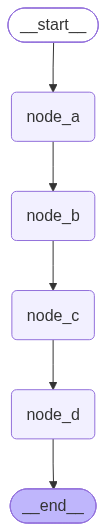

In [2]:
from langgraph.graph import StateGraph,START,END,MessagesState
from IPython.display import display,Image
import time

def node_a(state : MessagesState) -> MessagesState:
    print("Adding A","\n")
    time.sleep(1)
    return {"messages":"I am A"}

def node_b(state : MessagesState) -> MessagesState:
    print("Adding B","\n")
    time.sleep(1)
    return {"messages":"I am B"}

def node_c(state : MessagesState) -> MessagesState:
    print("Adding C","\n")
    time.sleep(1)
    return {"messages":"I am C"}

def node_d(state : MessagesState) -> MessagesState:
    print("Adding D","\n")
    time.sleep(1)
    return {"messages":"I am D"}


builder = StateGraph(MessagesState)

builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("node_c",node_c)
builder.add_node("node_d",node_d)


builder.add_edge(START,"node_a")
builder.add_edge("node_a","node_b")
builder.add_edge("node_b","node_c")
builder.add_edge("node_c","node_d")
builder.add_edge("node_d",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))



Using invoke (only final ouput is obtained)

In [5]:
res = graph.invoke({"messages":"I am vishwa"})
mes = res.get("messages")
mes

# for r in res.get("messages"):
#     r.pretty_print()

Adding A 

Adding B 

Adding C 

Adding D 



[HumanMessage(content='I am vishwa', additional_kwargs={}, response_metadata={}, id='231a5576-c9b0-4f4e-8876-57e7ab3332fc'),
 HumanMessage(content='I am A', additional_kwargs={}, response_metadata={}, id='f78e0853-f937-4843-9855-591092782a8f'),
 HumanMessage(content='I am B', additional_kwargs={}, response_metadata={}, id='35a6c1ab-9610-4ce7-9623-107db43c6648'),
 HumanMessage(content='I am C', additional_kwargs={}, response_metadata={}, id='67b09e82-b3fc-4c10-a907-1052cda24523'),
 HumanMessage(content='I am D', additional_kwargs={}, response_metadata={}, id='594f0c09-b261-4f61-945e-4b7148e9a130')]

.stream, stream_mode='values' -> Will stream state output after each node ("With messages key in our case)

In [6]:
config = {"config":{"configurable":{"thread_id":2}}}

chunks  = graph.stream({"messages":"I am vishwa"},config=config,stream_mode="values")

for chunk in chunks:
    print(chunk,"\n")

{'messages': [HumanMessage(content='I am vishwa', additional_kwargs={}, response_metadata={}, id='7848acb7-6cad-4c7b-b8a9-708d8e1fedbb')]} 

Adding A 

{'messages': [HumanMessage(content='I am vishwa', additional_kwargs={}, response_metadata={}, id='7848acb7-6cad-4c7b-b8a9-708d8e1fedbb'), HumanMessage(content='I am A', additional_kwargs={}, response_metadata={}, id='b58173f6-e90e-4ed5-b78b-89bfc70f8fae')]} 

Adding B 

{'messages': [HumanMessage(content='I am vishwa', additional_kwargs={}, response_metadata={}, id='7848acb7-6cad-4c7b-b8a9-708d8e1fedbb'), HumanMessage(content='I am A', additional_kwargs={}, response_metadata={}, id='b58173f6-e90e-4ed5-b78b-89bfc70f8fae'), HumanMessage(content='I am B', additional_kwargs={}, response_metadata={}, id='0899fc32-f4c1-411d-8ca0-62035f3664b4')]} 

Adding C 

{'messages': [HumanMessage(content='I am vishwa', additional_kwargs={}, response_metadata={}, id='7848acb7-6cad-4c7b-b8a9-708d8e1fedbb'), HumanMessage(content='I am A', additional_kwargs=

.stream, stream_mode='updates' -> only streams the output of the nodes (for every node)

In [7]:
config = {"config":{"configurable":{"thread_id":2}}}

chunks  = graph.stream({"messages":"I am vishwa"},config=config,stream_mode="updates")

for chunk in chunks:
    print(chunk,"\n")

Adding A 

{'node_a': {'messages': 'I am A'}} 

Adding B 

{'node_b': {'messages': 'I am B'}} 

Adding C 

{'node_c': {'messages': 'I am C'}} 

Adding D 

{'node_d': {'messages': 'I am D'}} 



.stream, stream_mode='messages' -> only streams the output of LLM calls

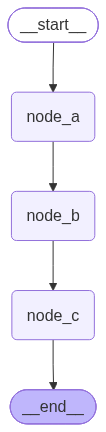

In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from IPython.display import display, Image
from langchain_core.messages import SystemMessage, HumanMessage


def node_a(state:MessagesState) -> MessagesState:
    print("Adding A", "\n")
    last_msg = state["messages"][-1].content
    google_llm.invoke("What is 2+2? Just give the answer")
    return {'messages': google_llm.invoke
    ([SystemMessage(content="Take the following text and append the letter 'A' to the end. Return ONLY the modified text."), HumanMessage(content=last_msg)])}

def node_b(state:MessagesState) -> MessagesState:
    print("Adding B", "\n")
    last_msg = state["messages"][-1].content
    return {'messages': google_llm.invoke
    ([SystemMessage(content="Take the following text and append the letter 'B' to the end. Return ONLY the modified text."), HumanMessage(content=last_msg)])}

def node_c(state:MessagesState) -> MessagesState:
    print("Adding C", "\n")
    last_msg = state["messages"][-1].content
    return {'messages': google_llm.invoke
    ([SystemMessage(content="Take the following text and append the letter 'C' to the end. Return ONLY the modified text."), HumanMessage(content=last_msg)])}


builder = StateGraph(MessagesState)

builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)


builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
config = {"config":{"configurable":{"thread_id":123}}}

chunks  = graph.stream({"messages":"I am vishwa"},config=config,stream_mode="messages")

for chunk in chunks:
    print(chunk,"\n")

Adding A 

(AIMessageChunk(content=[{'type': 'text', 'text': '4', 'index': 0}], additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fb7f8-58fb-7290-b68f-c52bc71d4efa', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 1, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}}, tool_call_chunks=[]), {'ls_integration': 'langchain_chat_model', 'langgraph_step': 1, 'langgraph_node': 'node_a', 'langgraph_triggers': ('branch:to:node_a',), 'langgraph_path': ('__pregel_pull', 'node_a'), 'langgraph_checkpoint_ns': 'node_a:c89c43aa-b795-c690-9e3f-e1c44e055d7a', 'checkpoint_ns': 'node_a:c89c43aa-b795-c690-9e3f-e1c44e055d7a', 'ls_provider': 'google_genai', 'ls_model_name': 'gemini-3.5-flash-lite', 'ls_model_type': 'chat', 'ls_temperature': 0.0, 'ls_max_tokens': 200, 'lc_versions': {'langchain-core': '1.5.2', 'langchain': '1.3.14', 'langchain-google-genai': '4.3.2'}}) 

(AIMessageChunk(conten